In [72]:
import numpy as np 
import pandas as pd  
import os
import matplotlib.pyplot as plt
import seaborn as sns
light_blue = "#87CEFA"
red = "#FF0000"

In [73]:
pd.read_csv('/kaggle/input/datasets/vedikagupta0/climate-risk-health-prediction-challenge/SampleSubmission.csv').sample(5)

,ID,TargetF1,TargetRAUC
305,ID_E2FB9F7C,0,0
801,ID_7B9B4263,0,0
638,ID_134EC5DE,0,0
1025,ID_911AD860,0,0
220,ID_14555504,0,0


In [74]:
data_dict =pd.read_csv('/kaggle/input/datasets/vedikagupta0/climate-risk-health-prediction-challenge/data_dictionary.csv')

In [75]:
df = pd.read_csv('/kaggle/input/datasets/vedikagupta0/climate-risk-health-prediction-challenge/Train.csv')

In [76]:
df["is_climate_sensitive"].value_counts()

is_climate_sensitive
1    2047
0    1099
Name: count, dtype: int64

In [77]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3146 entries, 0 to 3145
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   ID                    3146 non-null   object 
 1   zone                  3146 non-null   object 
 2   gender                3146 non-null   object 
 3   deathdate             3146 non-null   object 
 4   age                   3146 non-null   float64
 5   avg_temperature       3146 non-null   float64
 6   max_temperature       3146 non-null   float64
 7   min_temperature       3146 non-null   float64
 8   precipitation         3146 non-null   float64
 9   latitude              3146 non-null   float64
 10  longitude             3146 non-null   float64
 11  location              3146 non-null   object 
 12  is_climate_sensitive  3146 non-null   int64  
dtypes: float64(7), int64(1), object(5)
memory usage: 319.6+ KB


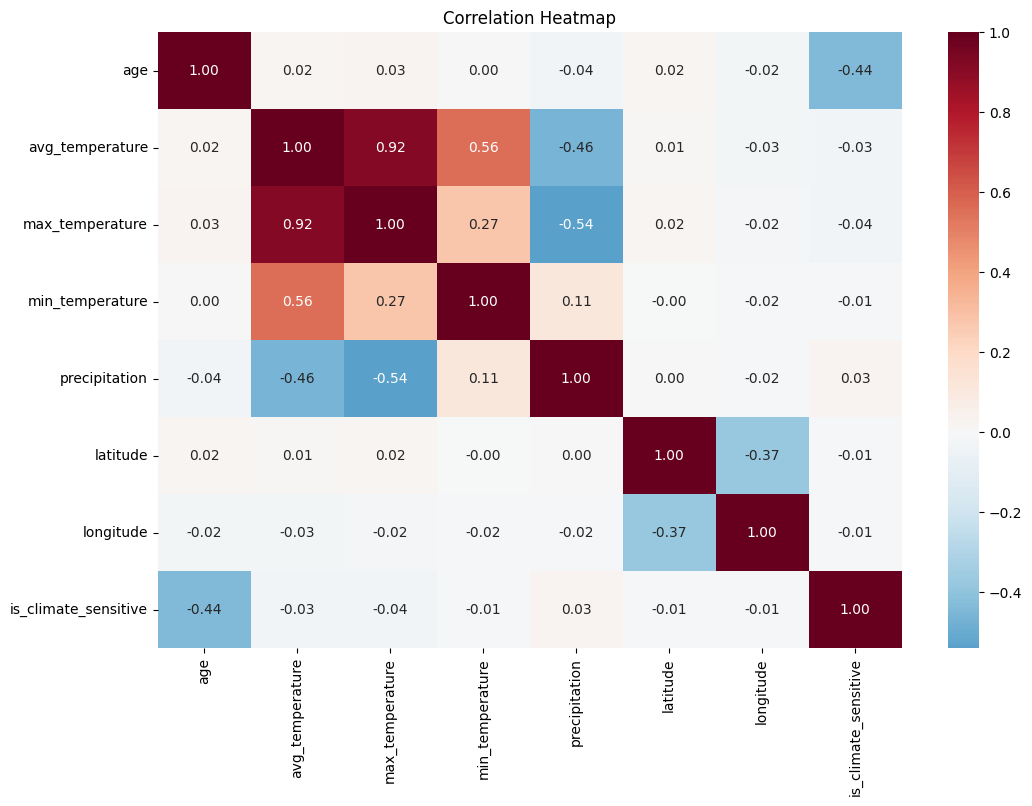

In [85]:
plt.figure(figsize=(12, 8))

corr = df.select_dtypes(include="number").corr()

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0
)

plt.title("Correlation Heatmap")
plt.show()

* #### max temperature drives the average temperature to be skewed towards it.
* #### target variable is moderate negatively correlated with age (-0.44). Significantly young people are connected more with `is_climate_sensitive`.


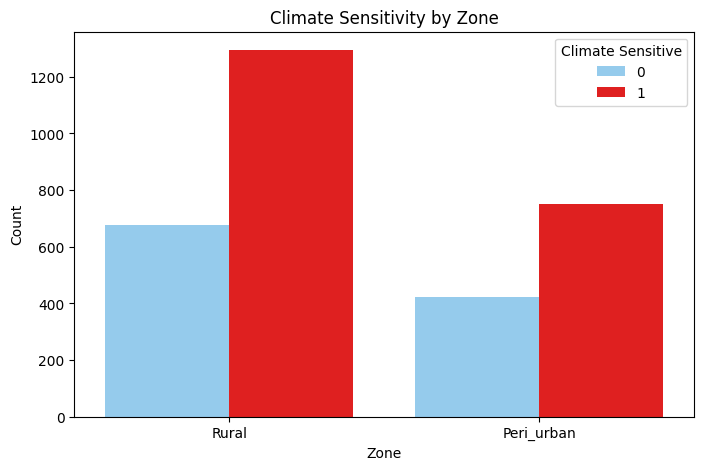

In [79]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="zone",
    hue="is_climate_sensitive",
    palette={0: light_blue, 1: red}
)

plt.title("Climate Sensitivity by Zone")
plt.xlabel("Zone")
plt.ylabel("Count")
plt.legend(title="Climate Sensitive")
plt.show()

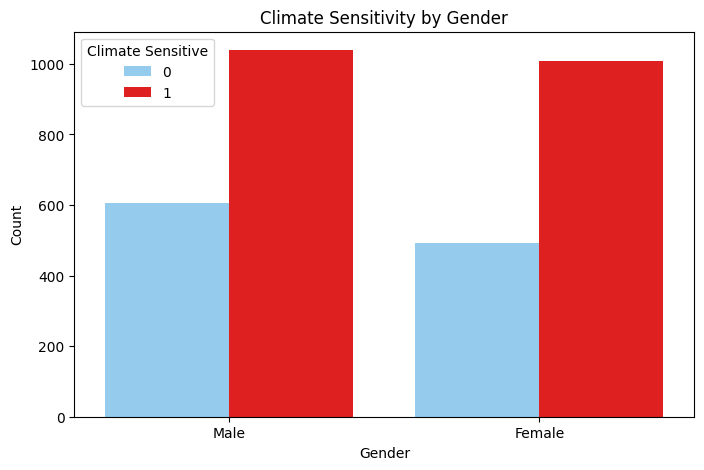

In [80]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="gender",
    hue="is_climate_sensitive",
    palette={0: light_blue, 1: red}
)

plt.title("Climate Sensitivity by Gender")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.legend(title="Climate Sensitive")
plt.show()

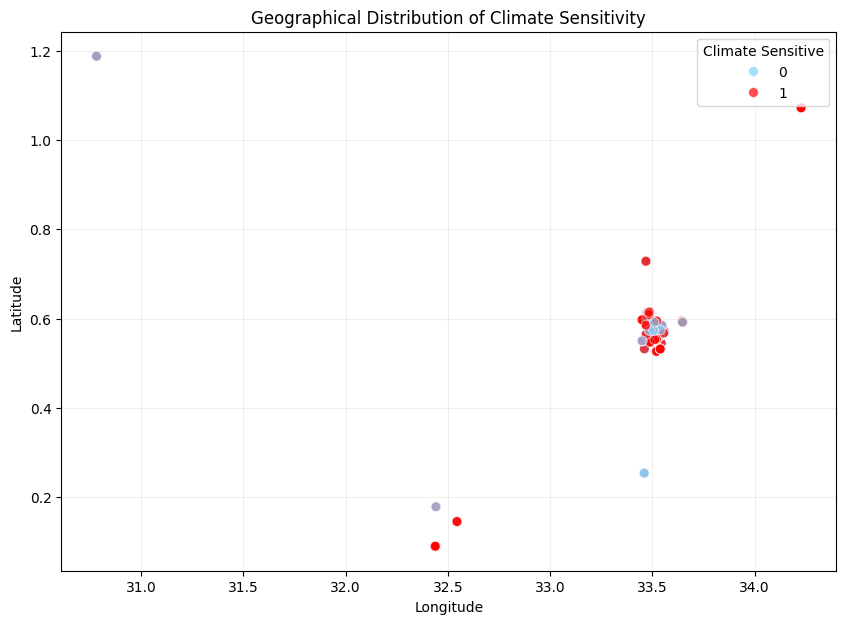

In [81]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=df,
    x="longitude",
    y="latitude",
    hue="is_climate_sensitive",
    palette={0: light_blue, 1: red},
    alpha=0.7,
    s=50
)

plt.title("Geographical Distribution of Climate Sensitivity")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend(title="Climate Sensitive")
plt.grid(alpha=0.2)
plt.show()

* #### more climate sensitive demographically is observed at latitude ~ 0.6 and longitude ~ 33.5.

In [92]:
df[df['latitude'].between(0.4, 0.65) & df['longitude'].between(33.5, 33.8)]['is_climate_sensitive'].value_counts()

is_climate_sensitive
1    670
0    354
Name: count, dtype: int64

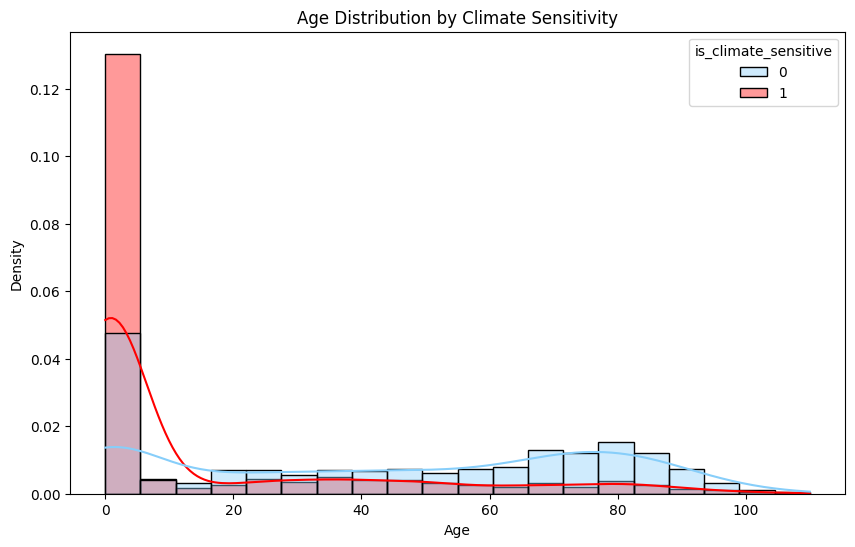

In [82]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="age",
    hue="is_climate_sensitive",
    bins=20,
    kde=True,
    stat="density",
    common_norm=False,
    palette={0: light_blue, 1: red},
    alpha=0.4
)

plt.title("Age Distribution by Climate Sensitivity")
plt.xlabel("Age")
plt.ylabel("Density")
plt.show()

* #### as suggested earlier, kids aged less than 10 are highly affected by climate sensitivity. One verdict is that the data holds more entries for kids in the dataset.

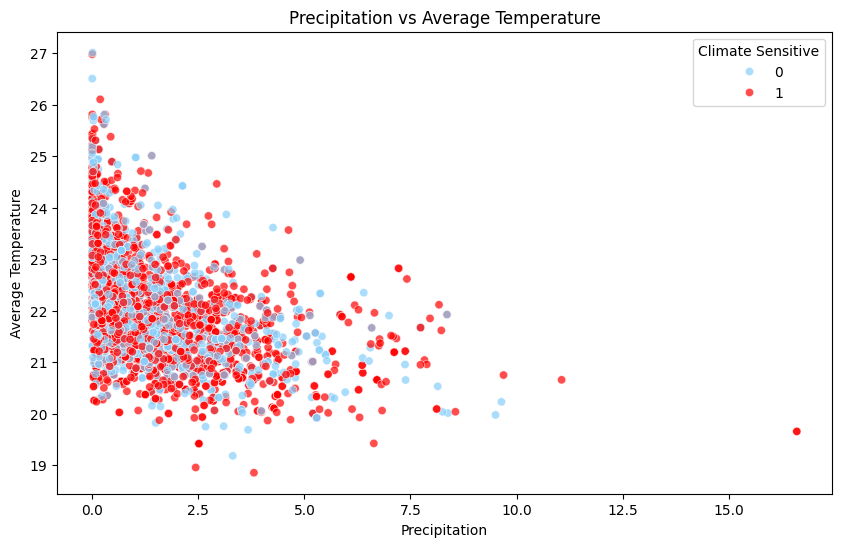

In [83]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="precipitation",
    y="avg_temperature",
    hue="is_climate_sensitive",
    palette={0: light_blue, 1: red},
    alpha=0.7
)

plt.title("Precipitation vs Average Temperature")
plt.xlabel("Precipitation")
plt.ylabel("Average Temperature")
plt.legend(title="Climate Sensitive")
plt.show()

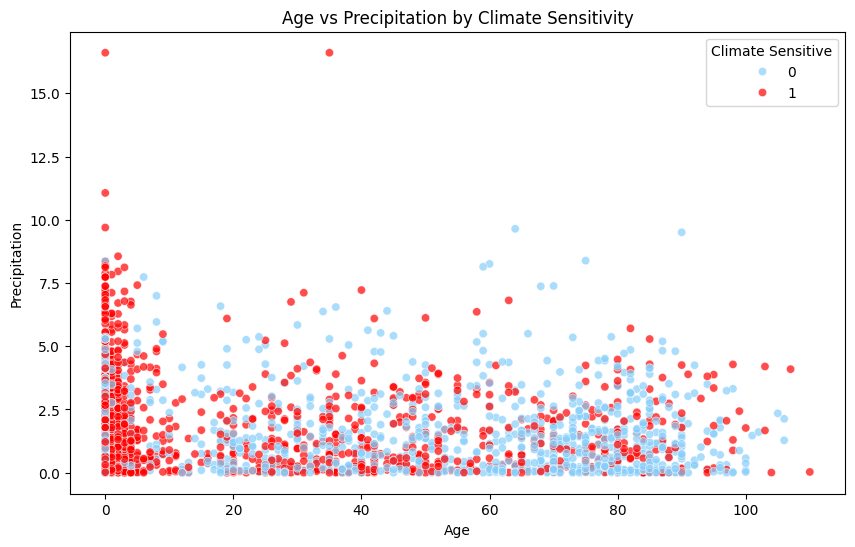

In [84]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="age",
    y="precipitation",
    hue="is_climate_sensitive",
    palette={0: light_blue, 1: red},
    alpha=0.7
)

plt.title("Age vs Precipitation by Climate Sensitivity")
plt.xlabel("Age")
plt.ylabel("Precipitation")
plt.legend(title="Climate Sensitive")
plt.show()

* #### more climate sensitivity is observed for young age group irrespective of precipitation, suggesting kids are more climate sensitive whereas adults in most of the case, are not climate sensitive.